In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas
import pandas as pd

In [3]:
path_to_standart = r"\data\standard"

In [8]:
aligned = r"C:\Users\User\PycharmProjects\peripheral_nerve_model\Main_model\MRG_model\2_Sensory_Axons\data\standard\final_analysis\two_axons_fd5.7_ed0.1_aligned_eph_amp5.0\event_plots\first_spike\arrival_times.csv"

misaligned = r"C:\Users\User\PycharmProjects\peripheral_nerve_model\Main_model\MRG_model\2_Sensory_Axons\data\standard\final_analysis\two_axons_fd5.7_ed0.1_misaligned_eph_amp5.0\event_plots\first_spike\arrival_times.csv"

no_ec = r"C:\Users\User\PycharmProjects\peripheral_nerve_model\Main_model\MRG_model\2_Sensory_Axons\data\standard\final_analysis\two_axons_fd5.7_ed0.1_noec_amp5.0\event_plots\first_spike\arrival_times.csv"

In [9]:
aligned = pd.read_csv(aligned)
misaligned = pd.read_csv(misaligned)
no_ec = pd.read_csv(no_ec)


In [10]:
aligned

,freq_hz,axon,site,arrival_ms,n_spikes
0,50.0,AxonA,before_like,10.2420,53
1,50.0,AxonA,main_like,10.3735,53
2,50.0,AxonA,terminal_main,11.0260,53
3,50.0,AxonB,after_branch_main,10.4140,53
4,50.0,AxonB,before_branch,10.2570,53
...,...,...,...,...,...
115,1000.0,AxonA,main_like,10.3735,1
116,1000.0,AxonA,terminal_main,11.0260,1
117,1000.0,AxonB,after_branch_main,10.4140,1
118,1000.0,AxonB,before_branch,10.2570,1


In [16]:
aligned_A = aligned[aligned["axon"] == "AxonA"].copy()
aligned_B = aligned[aligned["axon"] == "AxonB"].copy()

misaligned_A = misaligned[misaligned["axon"] == "AxonA"].copy()
misaligned_B = misaligned[misaligned["axon"] == "AxonB"].copy()

no_ec_A = no_ec[no_ec["axon"] == "AxonA"].copy()
no_ec_B = no_ec[no_ec["axon"] == "AxonB"].copy()

In [20]:
def compute_AB_difference(df_A, df_B):
    """
    Считает ΔAB = B - A для трёх точек:
    before, after, terminal
    """

    # --- соответствие сайтов ---
    mapping = {
        "before": ("before_like", "before_branch"),
        "after": ("main_like", "after_branch_main"),
        "terminal": ("terminal_main", "terminal_main"),
    }

    results = []

    freqs = sorted(df_A["freq_hz"].unique())

    for f in freqs:
        A_sub = df_A[df_A["freq_hz"] == f]
        B_sub = df_B[df_B["freq_hz"] == f]

        row = {"freq_hz": f}

        for key, (site_A, site_B) in mapping.items():
            A_val = A_sub[A_sub["site"] == site_A]["arrival_ms"].values[0]
            B_val = B_sub[B_sub["site"] == site_B]["arrival_ms"].values[0]

            row[f"{key}_A"] = A_val
            row[f"{key}_B"] = B_val
            row[f"{key}_dBA"] = B_val - A_val

        results.append(row)

    return pd.DataFrame(results)

In [21]:
aligned_diff = compute_AB_difference(aligned_A, aligned_B)
misaligned_diff = compute_AB_difference(misaligned_A, misaligned_B)
no_ec_diff = compute_AB_difference(no_ec_A, no_ec_B)

In [29]:
aligned_diff

,freq_hz,before_A,before_B,before_dBA,after_A,after_B,after_dBA,terminal_A,terminal_B,terminal_dBA
0,50.0,10.242,10.257,0.015,10.3735,10.414,0.0405,11.026,11.175,0.149
1,100.0,10.242,10.257,0.015,10.3735,10.414,0.0405,11.026,11.175,0.149
2,150.0,10.242,10.257,0.015,10.3735,10.414,0.0405,11.026,11.175,0.149
3,200.0,10.242,10.257,0.015,10.3735,10.414,0.0405,11.026,11.175,0.149
4,250.0,10.242,10.257,0.015,10.3735,10.414,0.0405,11.026,11.175,0.149
5,300.0,10.242,10.257,0.015,10.3735,10.414,0.0405,11.026,11.175,0.149
6,350.0,10.242,10.257,0.015,10.3735,10.414,0.0405,11.026,11.175,0.149
7,400.0,10.242,10.257,0.015,10.3735,10.414,0.0405,11.026,11.175,0.149
8,450.0,10.242,10.257,0.015,10.3735,10.414,0.0405,11.026,11.175,0.149
9,500.0,10.242,10.257,0.015,10.3735,10.414,0.0405,11.026,11.175,0.149


In [30]:
no_ec_diff

,freq_hz,before_A,before_B,before_dBA,after_A,after_B,after_dBA,terminal_A,terminal_B,terminal_dBA
0,50.0,10.2415,10.256,0.0145,10.3725,10.412,0.0395,11.04,11.2295,0.1895
1,100.0,10.2415,10.256,0.0145,10.3725,10.412,0.0395,11.04,11.2295,0.1895
2,150.0,10.2415,10.256,0.0145,10.3725,10.412,0.0395,11.04,11.2295,0.1895
3,200.0,10.2415,10.256,0.0145,10.3725,10.412,0.0395,11.04,11.2295,0.1895
4,250.0,10.2415,10.256,0.0145,10.3725,10.412,0.0395,11.04,11.2295,0.1895
5,300.0,10.2415,10.256,0.0145,10.3725,10.412,0.0395,11.04,11.2295,0.1895
6,350.0,10.2415,10.256,0.0145,10.3725,10.412,0.0395,11.04,11.2295,0.1895
7,400.0,10.2415,10.256,0.0145,10.3725,10.412,0.0395,11.04,11.2295,0.1895
8,450.0,10.2415,10.256,0.0145,10.3725,10.412,0.0395,11.04,11.2295,0.1895
9,500.0,10.2415,10.256,0.0145,10.3725,10.412,0.0395,11.04,11.2295,0.1895


In [25]:
def compare_with_no_ec(no_ec, ec):
    out = pd.DataFrame()
    out["freq_hz"] = no_ec["freq_hz"]

    for part in ["before", "after", "terminal"]:
        out[f"{part}_noEC_minus_EC"] = no_ec[f"{part}_dBA"] - ec[f"{part}_dBA"]

    return out

In [26]:
aligned_vs_no = compare_with_no_ec(no_ec_diff, aligned_diff)
misaligned_vs_no = compare_with_no_ec(no_ec_diff, misaligned_diff)

In [27]:
aligned_vs_no

,freq_hz,before_noEC_minus_EC,after_noEC_minus_EC,terminal_noEC_minus_EC
0,50.0,-0.0005,-0.001,0.0405
1,100.0,-0.0005,-0.001,0.0405
2,150.0,-0.0005,-0.001,0.0405
3,200.0,-0.0005,-0.001,0.0405
4,250.0,-0.0005,-0.001,0.0405
5,300.0,-0.0005,-0.001,0.0405
6,350.0,-0.0005,-0.001,0.0405
7,400.0,-0.0005,-0.001,0.0405
8,450.0,-0.0005,-0.001,0.0405
9,500.0,-0.0005,-0.001,0.0405


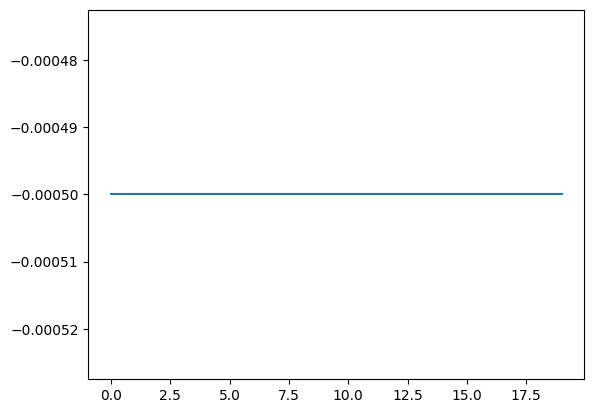

In [28]:
plt.plot(aligned_vs_no["before_noEC_minus_EC"])